# PolyGraphPy: A unified Python framework for atomistic simulation and machine learning-driven polymer design

This notebook demonstrates the workflow and capabilities of **PolyGraphPy**, a modular Python framework for atomistic simulation, molecular property prediction, and property-guided polymer generation. The analyses presented here replicate the results reported in the manuscript.

## 1. Environment Setup

We first import the required Python packages, including PyTorch, PyTorch Geometric, RDKit, DFTB+, and standard data analysis libraries.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem

import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
})
```

In [17]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole # Optional, for better rendering in notebooks

# The SMILES string provided
smiles_string = "CCOC(=O)/C=C/C1=C(C=CC(=C1)SCC2=CC=CC=C2)NC3=CC(=C(C=C3Cl)Cl)C"

# Generate the molecule object
mol = Chem.MolFromSmiles(smiles_string)

# Check if the molecule was parsed correctly
if mol:
    # Display the molecule
    # If running in a script, you might use: Draw.ShowMol(mol)
    # If in Jupyter, simply returning the object works, or use Draw.MolToImage
    img = Draw.MolToImage(mol, size=(600, 300))
    img.show() 
    # Or save it to a file
    img.save("molecule_structure.png")
    print("Molecule generated and saved as molecule_structure.png")
else:
    print("Error: Could not parse SMILES string.")

Molecule generated and saved as molecule_structure.png


## 2. Load and Inspect Monomer Dataset
We load the acrylate monomer dataset (1,263 entries) used in this study. We focus on key molecular descriptors such as molecular weight, polarizability index (computed using the proposed pipeline), Van der Waals volume, and refractive index.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem

import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
})

# Load original acrylate monomer dataset
df_original = pd.read_csv('df_polarizability_.csv')

# Select relevant columns and rename SMILES column
df_original = df_original.rename(columns={'smiles': 'smiles_A'})

# Display dataset size
print(f"Number of monomers in the dataset: {len(df_original)}")

Number of monomers in the dataset: 1263


## 3. Distribution of Molecular Descriptors

To better understand the acrylate monomer dataset, we visualize the distributions of key molecular descriptors using histograms. These descriptors provide insight into the chemical space and structural diversity of the monomers.

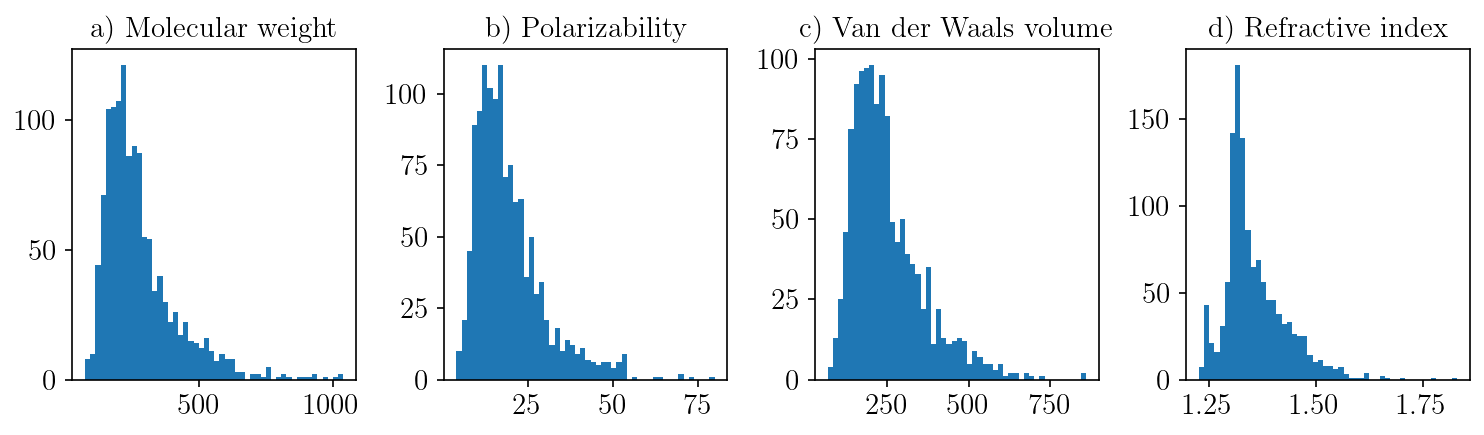

In [13]:
# Set up figure
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
axes = axes.flatten()  # Flatten for easy iteration

# Define descriptors and labels
descriptors = ['mw', 'static_polarizability', 'vdw_volume', 'refractive_index']
titles = ['a) Molecular weight', 'b) Polarizability', 'c) Van der Waals volume', 'd) Refractive index']

# Plot histograms
for ax, desc, title in zip(axes, descriptors, titles):
    ax.hist(df_original[desc], bins=50)
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig('../figures/Figure_12.pdf')

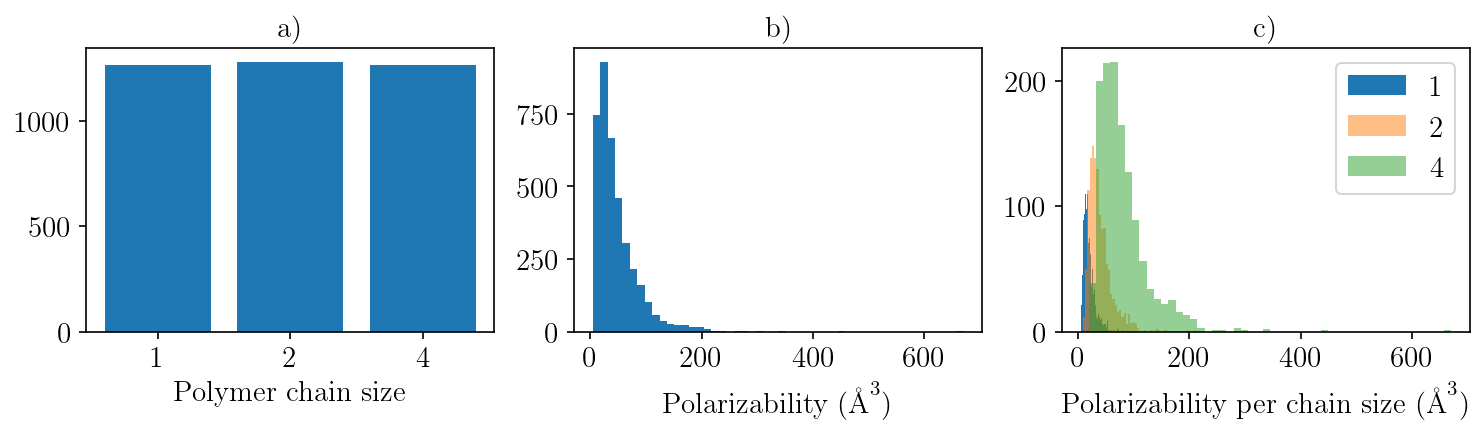

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

df_homopolymer = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_chain_size = df_homopolymer.groupby('chain_size').count().reset_index()

fig = plt.figure(figsize=(10, 3))

# ==========================================
# Subplot 1: Bar Chart (Fixed Spacing)
# ==========================================
plt.subplot(1, 3, 1)

# 1. Define arbitrary equidistant positions (0, 1, 2)
x_positions = range(len(df_chain_size)) 

# 2. Plot the data at these positions
plt.bar(x_positions, df_chain_size['id_A'])

# 3. Rename the ticks to display the actual chain sizes
# We assume the rows correspond to sizes 1, 2, 4 in that order
plt.xticks(x_positions, ['1', '2', '4'])

plt.xlabel('Polymer chain size')
plt.title('a)')

# ==========================================
# Subplot 2: Histogram
# ==========================================
plt.subplot(1, 3, 2)
plt.hist(df_homopolymer['static_polarizability'] * 0.14818471, bins=50)

# Added unit in LaTeX format
plt.xlabel(r'Polarizability ($\mathrm{\AA}^3$)') 
plt.title('b)')

# ==========================================
# Subplot 3: Overlaid Histogram
# ==========================================
plt.subplot(1, 3, 3)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 0]['static_polarizability'] * 0.14818471, bins=50, alpha=1, label='1')
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 1]['static_polarizability'] * 0.14818471, bins=50, alpha=0.5, label='2')
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 2]['static_polarizability'] * 0.14818471, bins=50, alpha=0.5, label='4')

# Added unit in LaTeX format
plt.xlabel(r'Polarizability per chain size ($\mathrm{\AA}^3$)')
plt.legend()
plt.title('c)')

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_13.pdf')

## 4. Static Polarizability of Monomers and Homopolymers

The atomistic simulation module of **PolyGraphPy** computes quantum mechanical properties using DFTB+, including the **static polarizability** of monomers and short polymer chains.  

Here, we load the dataset containing monomer/homopolymer (chain sizes 1, 2 and 4) and copolymer polarizabilities. The first contains 3,808 entries, the latter 8,627 contains with the following key columns:  

- `id_A` / `id_B`: ID of each monomer
- `smiles_A` / `smiles_B`: SMILES representation of monomers  
- `chain_size`: Length of the polymer chain: 
    - 0 flag for chain size equal 1
    - 1 flag for chain size equal 2
    - 2 flag for chain size equal 4
- `static_polarizability`: Computed polarizability in atomic units  
- `type`: Indicates whether the entry is a monomer, homopolymer, or copolymer  

Explanation:
- Missing values in id_B and smiles_B indicate entries corresponding to monomers or homopolymers.
- These datasets are used to analyze property distributions and validate GNN predictions.

In [17]:
# Load polarizability data for monomers/homopolymers and copolymers
df_homopolymer = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/polarizability_data_copoly.csv')

### 4.1 Visualizing Polarizability Distributions
We visualize the distribution of static polarizabilities using histograms and a boxplot. To avoid outliers affecting visualization, we exclude the top 10 sorted values.

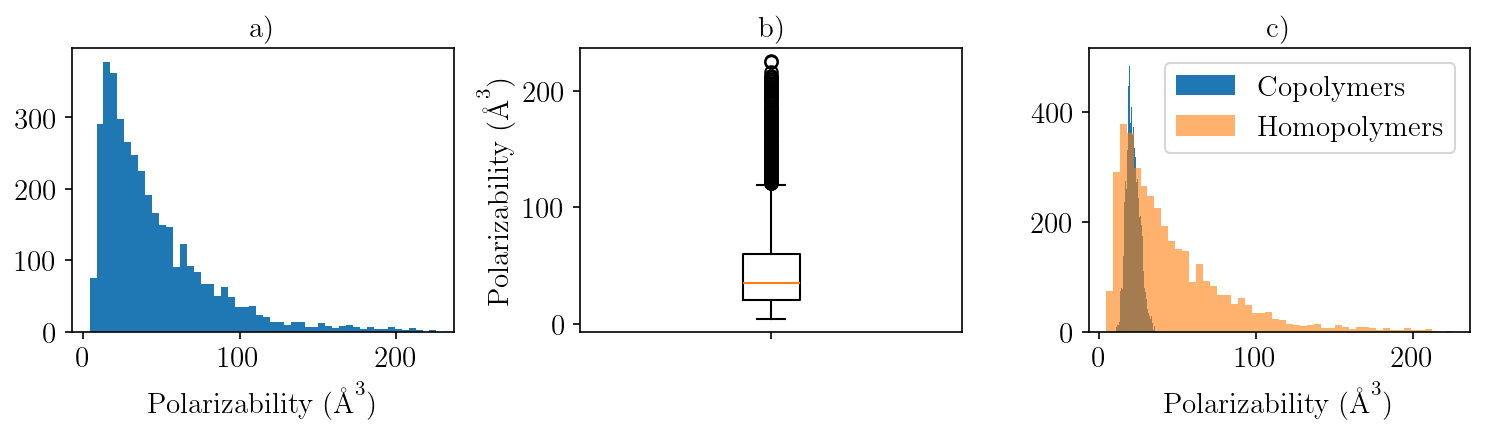

In [28]:
# Prepare figure
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# Subplot (a): Histogram of copolymer polarizabilities
axes[0].hist(df_homopolymer['static_polarizability'].sort_values()[:-10] * 0.14818471, bins=50)
axes[0].set_xlabel(r'Polarizability ($\mathrm{\AA}^3$)')
axes[0].set_title('a)')

# Subplot (b): Boxplot of copolymer polarizabilities
axes[1].boxplot(df_homopolymer['static_polarizability'].sort_values()[:-10] * 0.14818471)
axes[1].set_ylabel(r'Polarizability ($\mathrm{\AA}^3$)')
axes[1].set_title('b)')
axes[1].set_xticklabels([''])

# Subplot (c): Comparison histogram between copolymers and homopolymers
axes[2].hist(df_copolymer['static_polarizability'].sort_values()[:-10] * 0.14818471, bins=50, alpha=1, label='Copolymers')
axes[2].hist(df_homopolymer['static_polarizability'].sort_values()[:-10] * 0.14818471, bins=50, alpha=0.6, label='Homopolymers')
axes[2].set_xlabel(r'Polarizability ($\mathrm{\AA}^3$)')
axes[2].set_title('c)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Save figure
fig.savefig('../figures/Figure_14.pdf')


## 5. GNN Training Statistics

We trained a **GNN** model to predict static polarizabilities for monomers, homopolymers, and copolymers. Here, we visualize the **training and validation losses** over epochs for both datasets.

Explanation:
- The plots show mean squared error (MSE) loss for training and validation datasets over each epoch.
- Subplot (a) represents monomers and homopolymers; subplot (b) represents copolymers.

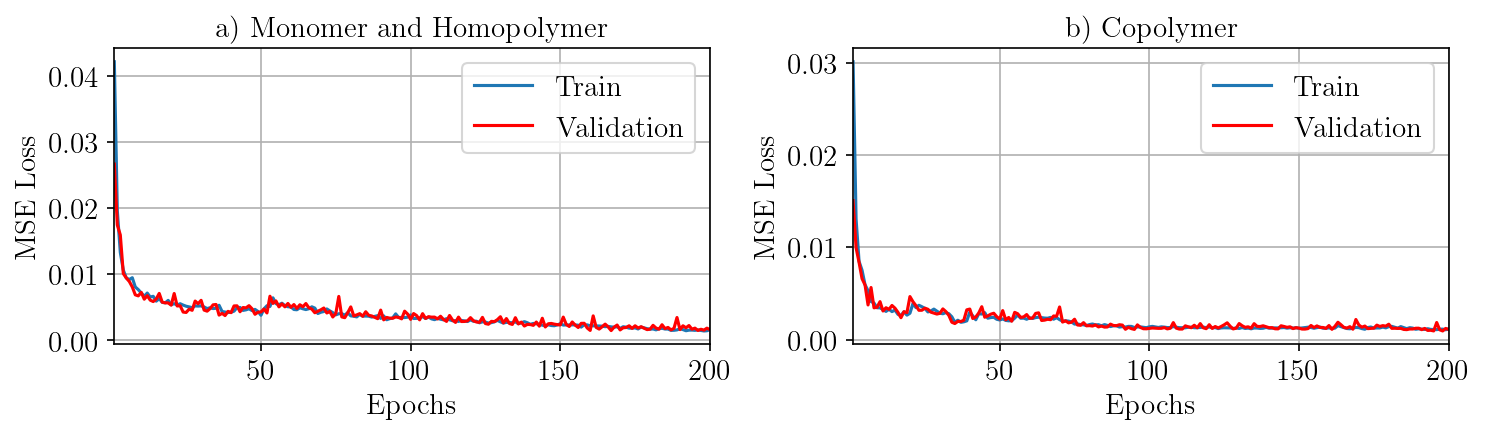

In [29]:
# Load training statistics
df_training_homopolymer = pd.read_csv('../polygraphpy/data/gnn_output/training_statistics.csv')
df_training_copolymer = pd.read_csv('../polygraphpy/data/gnn_output_copoly/training_statistics_copoly.csv')

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Subplot (a): Monomer and homopolymer training
axes[0].plot(df_training_homopolymer['epoch'] + 1, df_training_homopolymer['train_loss'], label='Train')
axes[0].plot(df_training_homopolymer['epoch'] + 1, df_training_homopolymer['val_loss'], 'r', label='Validation')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title('a) Monomer and Homopolymer')
axes[0].set_xlim([1, df_training_homopolymer['epoch'].max() + 1])
axes[0].grid(True)
axes[0].legend()

# Subplot (b): Copolymer training
axes[1].plot(df_training_copolymer['epoch'] + 1, df_training_copolymer['train_loss'], label='Train')
axes[1].plot(df_training_copolymer['epoch'] + 1, df_training_copolymer['val_loss'], 'r', label='Validation')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title('b) Copolymer')
axes[1].set_xlim([1, df_training_copolymer['epoch'].max() + 1])
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_15.pdf")

## 6. GNN Predictions vs. Ground Truth

We evaluate the performance of the GNN model by comparing predicted static polarizabilities against the original ground truth values for both monomers/homopolymers and copolymers.  

Since the model outputs were scaled during training using MinMaxScaler, we first **rescale predictions and ground truths** back to the original polarizability range.

Explanation:
- Each point represents one molecule (monomer, homopolymer, or copolymer).
- The red line represents perfect prediction (y = x). Points near this line indicate accurate predictions.
- Scatter density and deviation from the line provide a visual estimate of model performance.
- Rescaling ensures predictions are directly comparable to computed polarizabilities.
- These plots demonstrate that the GNN effectively captures the quantum mechanical property trends across both datasets.


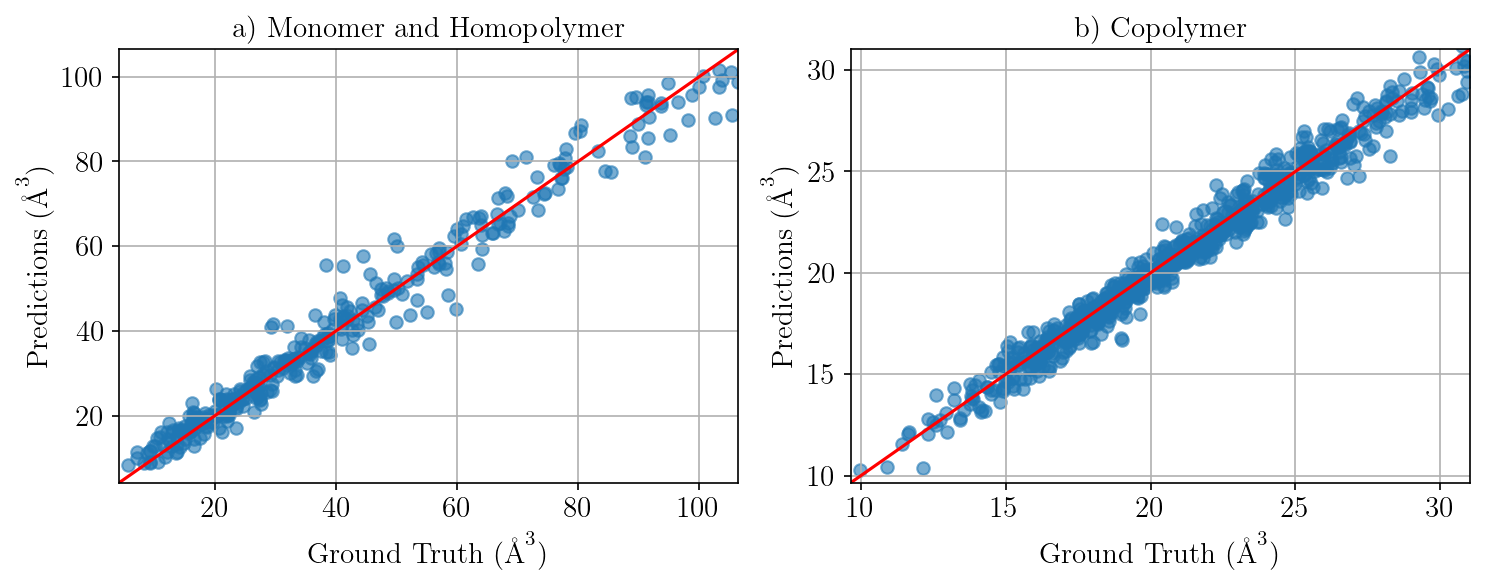

In [38]:
# Load prediction and ground truth datasets
df_pred_homopoly = pd.read_csv('../polygraphpy/data/gnn_output/df_results.csv')
df_original_homopoly = pd.read_csv('../polygraphpy/data/gnn_output/scaled_output.csv')
df_pred_copoly = pd.read_csv('../polygraphpy/data/gnn_output_copoly/df_results.csv')
df_original_copoly = pd.read_csv('../polygraphpy/data/gnn_output_copoly/scaled_output_copoly.csv')

# Retrieve original min and max for rescaling
min_max_homo = (df_original_homopoly['static_polarizability_original'].min() * 0.14818471,
                df_original_homopoly['static_polarizability_original'].max() * 0.14818471) 
min_max_copoly = (df_original_copoly['static_polarizability_original'].min() * 0.14818471,
                  df_original_copoly['static_polarizability_original'].max() * 0.14818471)

# Rescale predictions and ground truths
df_pred_homopoly['y_original'] = df_pred_homopoly['y'] * (min_max_homo[1] - min_max_homo[0]) + min_max_homo[0]
df_pred_homopoly['pred_original'] = df_pred_homopoly['pred'] * (min_max_homo[1] - min_max_homo[0]) + min_max_homo[0]

df_pred_copoly['y_original'] = df_pred_copoly['y'] * (min_max_copoly[1] - min_max_copoly[0]) + min_max_copoly[0]
df_pred_copoly['pred_original'] = df_pred_copoly['pred'] * (min_max_copoly[1] - min_max_copoly[0]) + min_max_copoly[0]

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Subplot (a): Monomer and homopolymer
axes[0].scatter(df_pred_homopoly['y_original'], df_pred_homopoly['pred_original'], alpha=0.6)
axes[0].plot([min_max_homo[0], min_max_homo[1]], [min_max_homo[0], min_max_homo[1]], 'r')
axes[0].set_xlabel(r"Ground Truth ($\mathrm{\AA}^3$)")
axes[0].set_ylabel(r"Predictions ($\mathrm{\AA}^3$)")
axes[0].set_title('a) Monomer and Homopolymer')
axes[0].set_xlim(min_max_homo)
axes[0].set_ylim(min_max_homo)
axes[0].grid(True)

# Subplot (b): Copolymer
axes[1].scatter(df_pred_copoly['y_original'], df_pred_copoly['pred_original'], alpha=0.6)
axes[1].plot([min_max_copoly[0], min_max_copoly[1]], [min_max_copoly[0], min_max_copoly[1]], 'r')
axes[1].set_xlabel(r"Ground Truth ($\mathrm{\AA}^3$)")
axes[1].set_ylabel(r"Predictions ($\mathrm{\AA}^3$)")
axes[1].set_title('b) Copolymer')
axes[1].set_xlim(min_max_copoly)
axes[1].set_ylim(min_max_copoly)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_16.pdf")

## 7. Uncertainty Estimation Using Monte Carlo Dropout

To quantify prediction uncertainty, we perform **Monte Carlo Dropout** on the validation set. This involves running the GNN model multiple times with dropout enabled during inference, producing a distribution of predictions for each molecule.  

Here, we visualize the **ensemble of predictions** for both monomers/homopolymers and copolymers.

Explanation:
- Each black line represents a single Monte Carlo dropout run, showing variability in predictions.
- The blue dotted line shows the mean of all 100 runs, providing a stable estimate of the predicted polarizability.
- The red line is the ground truth. Close alignment between the mean and ground truth indicates good predictive performance.
- Variability among the black lines reflects the model’s uncertainty in its predictions.
- Using Monte Carlo Dropout allows estimation of epistemic uncertainty in molecular property predictions, useful for guiding generative design or identifying high-confidence predictions.


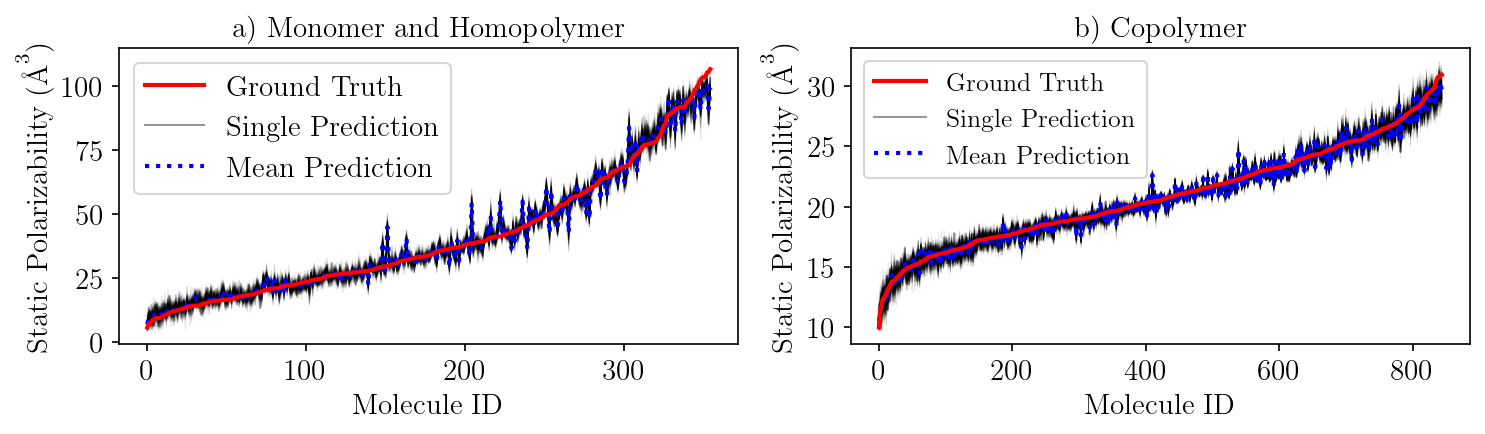

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BOHR_TO_ANGSTROM3 = 0.14818471

# 1. Load the original subset datasets to get LOCAL scaling parameters
df_orig_homo = pd.read_csv('../polygraphpy/data/gnn_output/scaled_output.csv')
df_orig_copo = pd.read_csv('../polygraphpy/data/gnn_output_copoly/scaled_output_copoly.csv')

# Calculate local Min and Max in Bohr^3
homo_min = df_orig_homo['static_polarizability_original'].min()
homo_max = df_orig_homo['static_polarizability_original'].max()

copo_min = df_orig_copo['static_polarizability_original'].min()
copo_max = df_orig_copo['static_polarizability_original'].max()

def process_data(df_scaled, local_min, local_max):
    """
    1. Unscales data using subset-specific MinMax.
    2. Converts from Bohr^3 to Angstrom^3.
    """
    # Inverse MinMax: x_raw = x_scaled * (max - min) + min
    df_unscaled = df_scaled * (local_max - local_min) + local_min
    
    # Unit Conversion
    df_final = df_unscaled * BOHR_TO_ANGSTROM3
    return df_final

# 2. Load Monte Carlo Dropout results
df_homopolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_homopolymer.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_copolymer.csv')

# 3. Apply transformation using the LOCAL min and max
df_homo_final = process_data(df_homopolymer, homo_min, homo_max)
df_copo_final = process_data(df_copolymer, copo_min, copo_max)

# 4. Set up figure (The rest of your plotting code remains unchanged)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# --- Helper function for consistent plotting ---
def plot_uq(ax, df, title):
    for i in range(100):
        col_name = f'run_{i}'
        if col_name in df.columns:
            ax.plot(df.index, df[col_name], color='k', alpha=0.1, linewidth=0.5)

    pred_cols = [c for c in df.columns if 'run_' in c]
    mean_pred = df[pred_cols].mean(axis=1)

    line_pred, = ax.plot(df.index, df['run_0'], 'k', linewidth=1, alpha=0.4, label='Predictions (Runs)')
    line_mean, = ax.plot(df.index, mean_pred, ':b', linewidth=2, label='Mean Prediction')
    line_gt, = ax.plot(df.index, df['y'], 'r', linewidth=2, label='Ground Truth')

    ax.set_title(title)
    ax.set_xlabel("Molecule ID")
    ax.set_ylabel(r"Static Polarizability ($\mathrm{\AA}^3$)")
    
    return [line_gt, line_pred, line_mean]

# --- Subplot (a): Monomer and Homopolymer ---
lines_a = plot_uq(axes[0], df_homo_final, 'a) Monomer and Homopolymer')
axes[0].legend(lines_a, ['Ground Truth', 'Single Prediction', 'Mean Prediction'])

# --- Subplot (b): Copolymer ---
lines_b = plot_uq(axes[1], df_copo_final, 'b) Copolymer')
axes[1].legend(lines_b, ['Ground Truth', 'Single Prediction', 'Mean Prediction'], fontsize=12.5)

plt.tight_layout()
plt.show()

fig.savefig("../figures/Figure_17.pdf")

## 8. Molecular Prediction Uncertainty: Standard Deviation

To quantify the **uncertainty of predictions** for each molecule, we compute the **standard deviation** across the 100 Monte Carlo Dropout runs.  
Higher standard deviation indicates higher model uncertainty for a given molecule.

Explanation:
- Each point represents the standard deviation of 100 Monte Carlo Dropout runs for a single molecule.
- Large deviations indicate molecules where the model is less confident.
- This plot complements the ensemble prediction visualization, providing a quantitative measure of uncertainty across the dataset.
- Such metrics are valuable for identifying molecules that may require additional atomistic simulations or experimental validation.


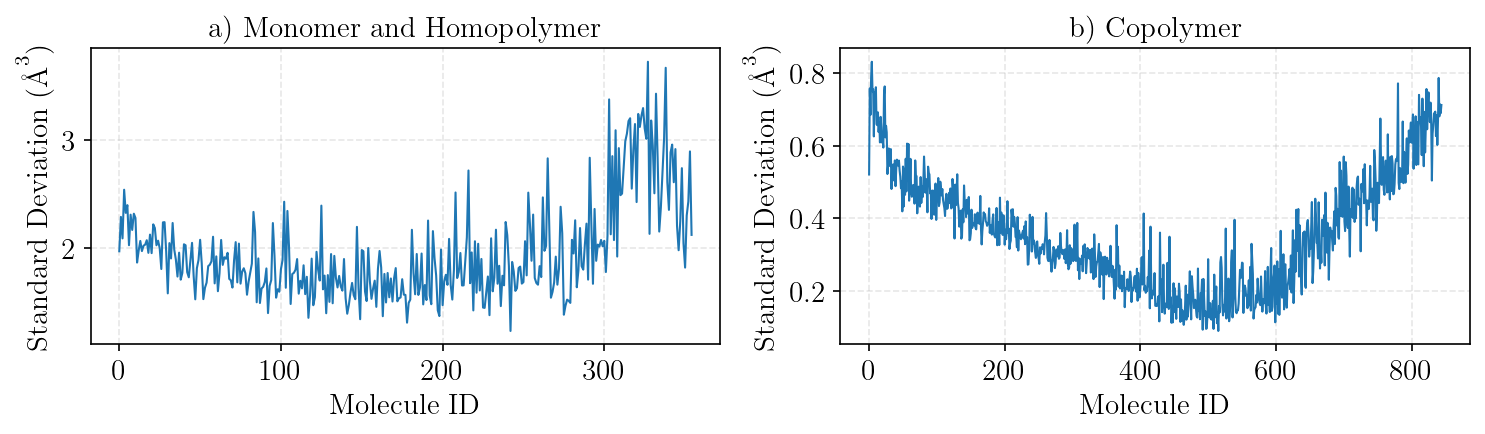

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

BOHR_TO_ANGSTROM3 = 0.14818471

# 1. Load Local Data & Get Specific Scaling Factors
# We need the range from the original local data subsets to unscale the std dev correctly
df_orig_homo = pd.read_csv('../polygraphpy/data/gnn_output/scaled_output.csv')
df_orig_copo = pd.read_csv('../polygraphpy/data/gnn_output_copoly/scaled_output_copoly.csv')

homo_range = df_orig_homo['static_polarizability_original'].max() - df_orig_homo['static_polarizability_original'].min()
copo_range = df_orig_copo['static_polarizability_original'].max() - df_orig_copo['static_polarizability_original'].min()

# The total factors to convert scaled std -> physical std (Angstrom^3)
HOMO_STD_SCALE = homo_range * BOHR_TO_ANGSTROM3
COPO_STD_SCALE = copo_range * BOHR_TO_ANGSTROM3

# 2. Load Monte Carlo Dropout results
df_homopolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_homopolymer.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_copolymer.csv')

# 3. Compute Unscaled Standard Deviations
# We calculate the std of the scaled data first, then apply the specific subset factor
std_homo = df_homopolymer.drop(columns='y').std(axis=1) * HOMO_STD_SCALE
std_copo = df_copolymer.drop(columns='y').std(axis=1) * COPO_STD_SCALE

# 4. Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Subplot (a): Monomer and homopolymer
axes[0].plot(df_homopolymer.index, std_homo, linewidth=1, color='#1f77b4') 
axes[0].set_title('a) Monomer and Homopolymer')
axes[0].set_xlabel("Molecule ID")
axes[0].set_ylabel(r"Standard Deviation ($\mathrm{\AA}^3$)")
axes[0].grid(True, linestyle='--', alpha=0.3)

# Subplot (b): Copolymer
axes[1].plot(df_copolymer.index, std_copo, linewidth=1, color='#1f77b4')
axes[1].set_title('b) Copolymer')
axes[1].set_xlabel("Molecule ID")
axes[1].set_ylabel(r"Standard Deviation ($\mathrm{\AA}^3$)")
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_18.pdf")

## 9. Distribution of Prediction Errors

To assess the accuracy and reliability of the GNN model, we analyze the distribution of prediction metrics across the validation set:

- **MAPE (%)**: Mean Absolute Percentage Error  
- **R²**: Coefficient of determination  
- **MSE (%)**: Mean Squared Error, scaled by 100 for visualization  

We visualize the distributions using **Kernel Density Estimation (KDE)** plots for both monomer/homopolymer and copolymer datasets.

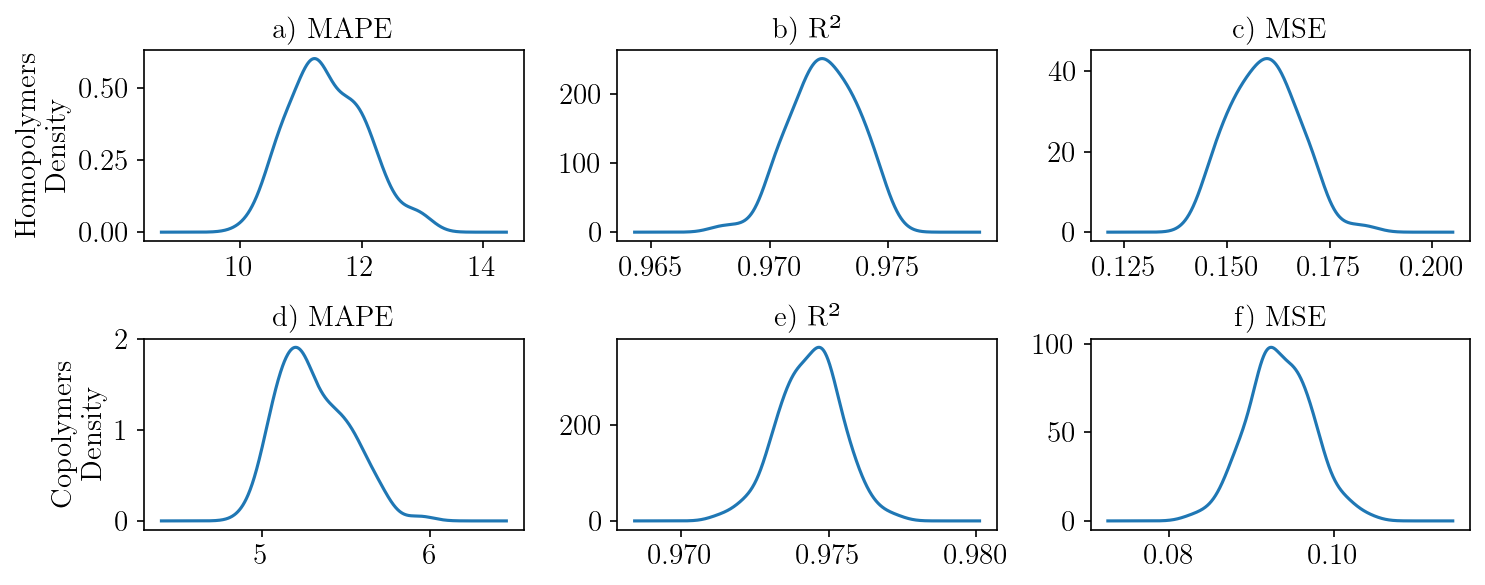

In [50]:
# Load error metrics
df_homopolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_error_homopolymer.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_error_copolymer.csv')

# Scale MSE for visualization
df_homopolymer['mse'] = 100 * df_homopolymer['mse']
df_copolymer['mse'] = 100 * df_copolymer['mse']

# Set up figure
fig, axes = plt.subplots(2, 3, figsize=(10, 4))

# Monomer and homopolymer KDEs
df_homopolymer['mape'].plot.kde(ax=axes[0, 0])
axes[0, 0].set_title('a) MAPE')
axes[0, 0].set_ylabel('Homopolymers\nDensity')

df_homopolymer['r2'].plot.kde(ax=axes[0, 1])
axes[0, 1].set_title('b) R²')
axes[0, 1].set_ylabel('')

df_homopolymer['mse'].plot.kde(ax=axes[0, 2])
axes[0, 2].set_title('c) MSE')
axes[0, 2].set_ylabel('')

# Copolymer KDEs
df_copolymer['mape'].plot.kde(ax=axes[1, 0])
axes[1, 0].set_title('d) MAPE')
axes[1, 0].set_ylabel('Copolymers\nDensity')

df_copolymer['r2'].plot.kde(ax=axes[1, 1])
axes[1, 1].set_title('e) R²')
axes[1, 1].set_ylabel('')

df_copolymer['mse'].plot.kde(ax=axes[1, 2])
axes[1, 2].set_title('f) MSE')
axes[1, 2].set_ylabel('')

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_19.pdf")

## 10. Analysis of Genetic Algorithm-Based Monomer Generation

To evaluate the performance of the **Genetic Algorithm (GA) generative model**, we analyze the predicted fitness values relative to their target polarizabilities.  

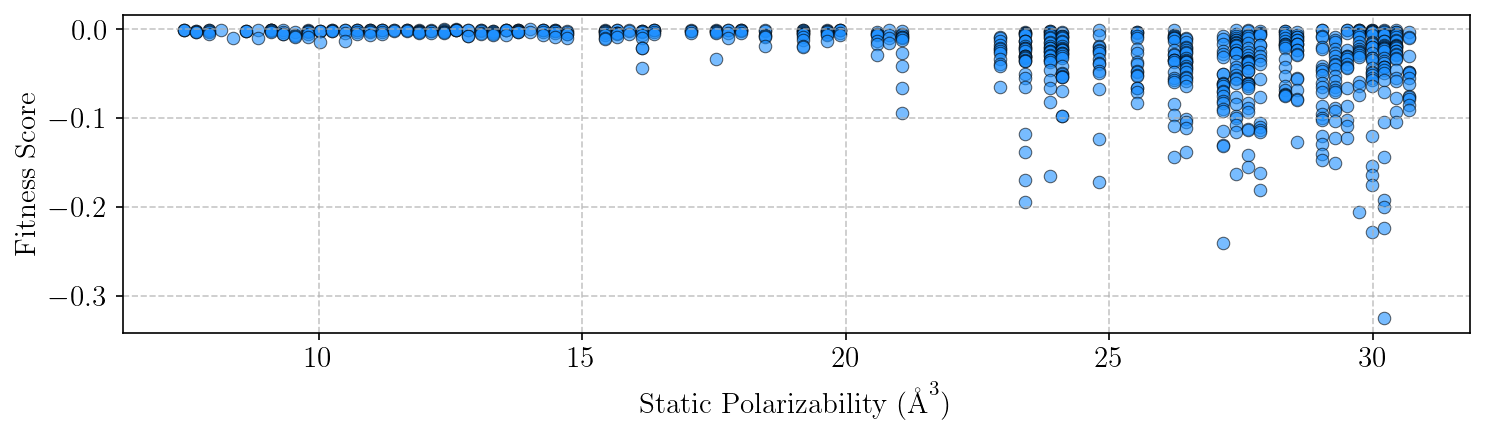

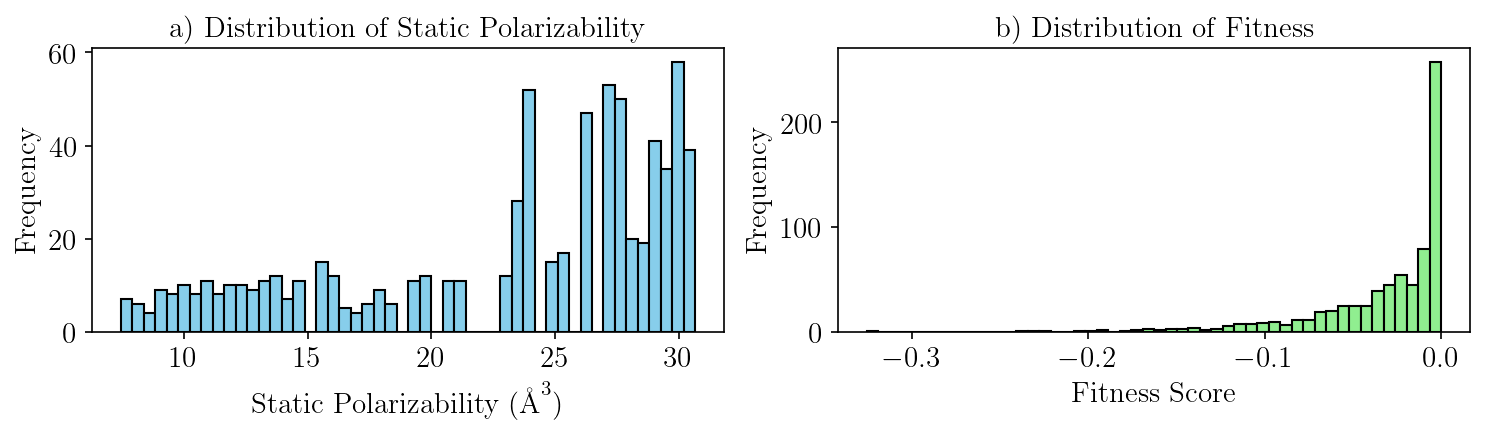

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw

# ==========================================
# 1. Unscaling Logic
# ==========================================
BOHR_TO_ANGSTROM3 = 0.14818471

# Load the original subset dataset to get LOCAL scaling parameters for monomers
df_orig_homo = pd.read_csv('../polygraphpy/data/gnn_output/scaled_output.csv')

homo_min = df_orig_homo['static_polarizability_original'].min()
homo_max = df_orig_homo['static_polarizability_original'].max()

# Load the generated molecules
df = pd.read_csv('../polygraphpy/data/ga_output/generated_molecules.csv')

# Unscale: x_raw = x_scaled * (max - min) + min, then convert to Angstrom^3
df['static_polarizability_unscaled'] = df['static_polarizability'] * (homo_max - homo_min) + homo_min
df['static_polarizability_unscaled'] = df['static_polarizability_unscaled'] * BOHR_TO_ANGSTROM3

# ==========================================
# 2. Scatter plot: Property vs. Fitness
# ==========================================
plt.figure(figsize=(10, 3))
plt.scatter(df['static_polarizability_unscaled'], df['fitness'], 
            alpha=0.6, c='dodgerblue', edgecolors='k', linewidth=0.5)
plt.xlabel(r'Static Polarizability ($\mathrm{\AA}^3$)')
plt.ylabel('Fitness Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../figures/Figure_20.pdf')
plt.show()

# ==========================================
# 3. Histograms of Distributions
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(df['static_polarizability_unscaled'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('a) Distribution of Static Polarizability')
axes[0].set_xlabel(r'Static Polarizability ($\mathrm{\AA}^3$)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['fitness'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('b) Distribution of Fitness')
axes[1].set_xlabel('Fitness Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../figures/Figure_21.pdf')
plt.show()

## 11. Novelty Assessment of Generated Molecules

To evaluate the **novelty** of the generated molecules, we check which SMILES strings are **already present** in the original acrylate dataset.  
This provides insight into whether the generative model proposes **new chemical structures** or reproduces existing ones.

In [65]:
import pandas as pd

# Load GA-generated molecules and original dataset
df_generated = pd.read_csv('../polygraphpy/data/ga_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

# Consider only monomers in original dataset (chain_size == 0)
df_original = df_original[df_original['chain_size'] == 0]

# Remove duplicates from generated molecules
df_unique = df_generated.drop_duplicates(subset='smiles')

# Compute fraction of generated molecules present in original dataset
fraction_present = len(df_unique[df_unique['smiles'].isin(df_original['smiles_A'])]) / len(df_unique)
novelty_fraction = 1 - fraction_present

print(f"Fraction of generated molecules that are novel: {novelty_fraction:.4f}")

Fraction of generated molecules that are novel: 0.8999


## 12. Analysis of GPT-Based Generative Model

We assess the GPT-based generative model in three aspects:

1. **Uniqueness** – fraction of generated SMILES that are distinct.  
2. **Novelty** – fraction of generated molecules not present in the original dataset.  
3. **Coverage** – polarizability values explored by the generated molecules.

Explanation:
- Uniqueness ensures the GPT model is not generating repeated molecules.
- Novelty measures how many generated molecules are new compared to the original dataset.
- Coverage examines the distribution of target polarizabilities to verify whether the model explores the desired property space comprehensively.
- Missing polarizability values indicate gaps in property-guided generation, which could guide further model refinement or sampling.


In [66]:
import pandas as pd
import numpy as np

# Load GPT-generated molecules and original dataset
df_generated = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

# Consider only monomers (chain_size == 0)
df_original = df_original[df_original['chain_size'] == 0]

# --- 1. Uniqueness ---
n_unique = len(df_generated['smiles_A'].drop_duplicates())
total_generated = len(df_generated['smiles_A'])
uniqueness_fraction = n_unique / total_generated
print(f"Fraction of unique generated molecules: {uniqueness_fraction:.4f}")

# --- 2. Novelty ---
novelty_fraction = 1 - df_generated['smiles_A'].drop_duplicates().isin(df_original['smiles_A']).sum() / n_unique
print(f"Fraction of novel molecules: {novelty_fraction:.4f}")

# --- 3. Polarizability Coverage ---
df_grouped = df_generated.groupby('static_polarizability').count()['smiles_A'].reset_index()
polarizability_series = pd.Series(np.linspace(0, 1, 200)).round(4)

# Identify polarizability bins not represented in generated dataset
missing_polarizabilities = polarizability_series[~polarizability_series.isin(df_generated['static_polarizability'].round(4))].values
print("Missing polarizabilities (not covered by generated molecules):", missing_polarizabilities)

Fraction of unique generated molecules: 0.9920
Fraction of novel molecules: 0.7823
Missing polarizabilities (not covered by generated molecules): [0.0352 0.0402 0.0503 0.0704 0.1658 0.1709 0.1759 0.1859 0.191  0.206
 0.2764 0.3166 0.3367 0.3467 0.3668 0.3769 0.3819 0.407  0.4171 0.4221
 0.4271 0.4472 0.4673 0.4774 0.4824 0.4925 0.5075 0.5226 0.5327 0.5377
 0.5427 0.5477 0.5578 0.5628 0.5678 0.593  0.598  0.603  0.6181 0.6432
 0.6482 0.6583 0.6633 0.6734 0.6834 0.6884 0.7085 0.7186 0.7337 0.7487
 0.7538 0.7688 0.7739 0.7889 0.794  0.799  0.804  0.8141 0.8191 0.8492
 0.8543 0.8593 0.8643 0.8744 0.8794 0.8894 0.8945 0.8995 0.9146 0.9447
 0.9648 0.9698 0.9749 0.9849 1.    ]


## 13. Visualization of GPT-Based Generation Accuracy

We evaluate the GPT-based model's ability to generate molecules with target polarizabilities by analyzing:

1. **Distribution of predicted polarizability** using histograms.
2. **Distribution of prediction errors** using histograms.

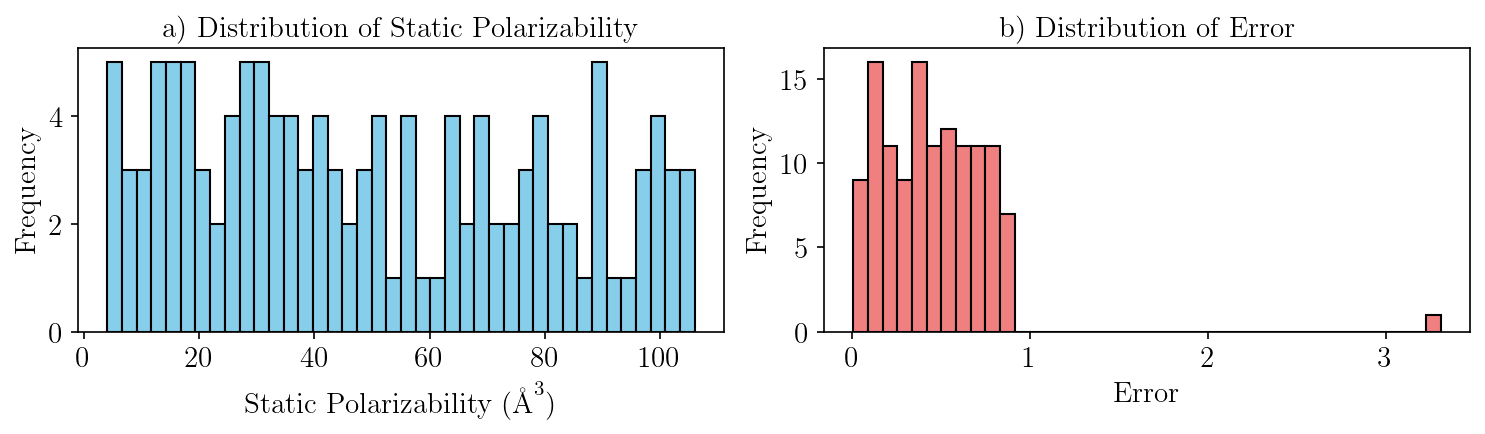

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw

# ==========================================
# 1. Unscaling Logic
# ==========================================
BOHR_TO_ANGSTROM3 = 0.14818471

# Load the original subset dataset to get LOCAL scaling parameters for monomers
df_orig_homo = pd.read_csv('../polygraphpy/data/gnn_output/scaled_output.csv')

homo_min = df_orig_homo['static_polarizability_original'].min()
homo_max = df_orig_homo['static_polarizability_original'].max()

# Load the GPT-generated molecules dataset
df = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')

# Unscale: x_raw = x_scaled * (max - min) + min, then convert to Angstrom^3
df['static_polarizability_unscaled'] = df['static_polarizability'] * (homo_max - homo_min) + homo_min
df['static_polarizability_unscaled'] = df['static_polarizability_unscaled'] * BOHR_TO_ANGSTROM3

df['static_polarizability_pred_unscaled'] = df['static_polarizability_pred'] * (homo_max - homo_min) + homo_min
df['static_polarizability_pred_unscaled'] = df['static_polarizability_pred_unscaled'] * BOHR_TO_ANGSTROM3

# ==========================================
# 3. Histograms of Distributions
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(df['static_polarizability_unscaled'], bins=40, color='skyblue', edgecolor='black')
axes[0].set_title('a) Distribution of Static Polarizability')
axes[0].set_xlabel(r'Static Polarizability ($\mathrm{\AA}^3$)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['error'], bins=40, color='lightcoral', edgecolor='black')
axes[1].set_title('b) Distribution of Error')
axes[1].set_xlabel('Error')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../figures/Figure_22.pdf')
plt.show()

In [4]:
import pandas as pd
import numpy as np

# Load GPT-generated molecules and original dataset
df_generated = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

# Consider only monomers (chain_size == 0)
df_original = df_original[df_original['chain_size'] == 0]

# --- 1. Uniqueness ---
n_unique = len(df_generated['smiles_A'].drop_duplicates())
total_generated = len(df_generated['smiles_A'])
uniqueness_fraction = n_unique / total_generated
print(f"Fraction of unique generated molecules: {uniqueness_fraction:.4f}")

# --- 2. Novelty ---
novelty_fraction = 1 - df_generated['smiles_A'].drop_duplicates().isin(df_original['smiles_A']).sum() / n_unique
print(f"Fraction of novel molecules: {novelty_fraction:.4f}")

# --- 3. Polarizability Coverage ---
df_grouped = df_generated.groupby('static_polarizability').count()['smiles_A'].reset_index()
polarizability_series = pd.Series(np.linspace(0, 1, 200)).round(4)

# Identify polarizability bins not represented in generated dataset
missing_polarizabilities = polarizability_series[~polarizability_series.isin(df_generated['static_polarizability'].round(4))].values
print("Missing polarizabilities (not covered by generated molecules):", missing_polarizabilities)

Fraction of unique generated molecules: 0.9920
Fraction of novel molecules: 0.7823
Missing polarizabilities (not covered by generated molecules): [0.0352 0.0402 0.0503 0.0704 0.1658 0.1709 0.1759 0.1859 0.191  0.206
 0.2764 0.3166 0.3367 0.3467 0.3668 0.3769 0.3819 0.407  0.4171 0.4221
 0.4271 0.4472 0.4673 0.4774 0.4824 0.4925 0.5075 0.5226 0.5327 0.5377
 0.5427 0.5477 0.5578 0.5628 0.5678 0.593  0.598  0.603  0.6181 0.6432
 0.6482 0.6583 0.6633 0.6734 0.6834 0.6884 0.7085 0.7186 0.7337 0.7487
 0.7538 0.7688 0.7739 0.7889 0.794  0.799  0.804  0.8141 0.8191 0.8492
 0.8543 0.8593 0.8643 0.8744 0.8794 0.8894 0.8945 0.8995 0.9146 0.9447
 0.9648 0.9698 0.9749 0.9849 1.    ]


# 14. Design space exploration capability

Running t-SNE on 2112 samples with features: ['mw', 'vdw_volume', 'static_polarizability', 'refractive_index']...


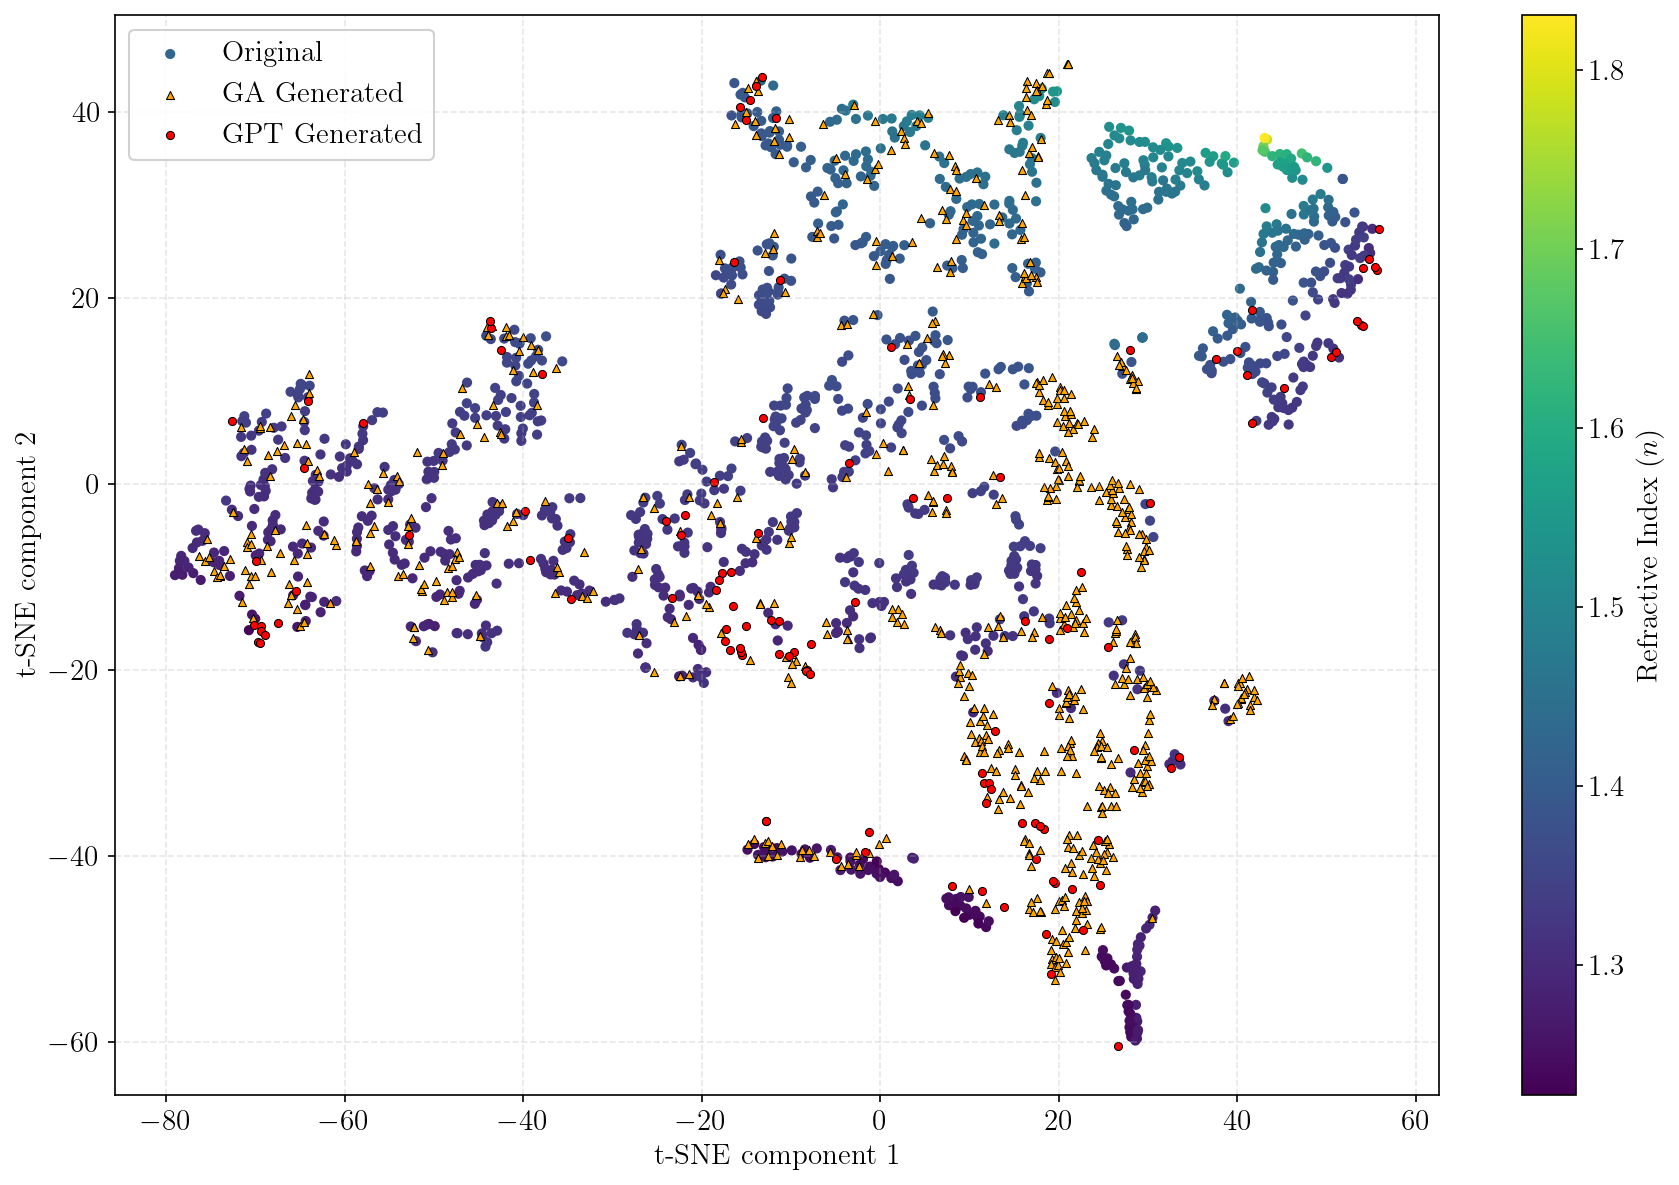

In [80]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

def get_rdkit_props(smiles):
    """
    Computes physical-chemical properties from a SMILES string using RDKit.
    Returns a pandas Series so it can be applied directly to a DataFrame.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    # Handle invalid SMILES generated by models
    if mol is None:
        return pd.Series([None], index=['mw'])
    
    return pd.Series({
        'mw': Descriptors.MolWt(mol),                 # Molecular Weight
    })

df_ga_output = pd.read_csv('df_ga_output.csv')
df_gpt_output = pd.read_csv('df_gpt_output.csv')
df_polarizability = pd.read_csv('df_polarizability_.csv')

df_ga_output['mw'] = df_ga_output['smiles'].apply(get_rdkit_props)
df_gpt_output['mw'] = df_gpt_output['smiles'].apply(get_rdkit_props)
df_polarizability['mw'] = df_polarizability['smiles'].apply(get_rdkit_props)

df_polarizability['static_polarizability'] = df_polarizability['static_polarizability']*0.14818471 #A^3
df_ga_output['static_polarizability_pred_original'] = df_ga_output['static_polarizability_pred_original']*0.14818471
df_gpt_output['static_polarizability_pred_original'] = df_gpt_output['static_polarizability_pred_original']*0.14818471

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Prepare Data
# ==========================================

# Define the features we want to use for the embedding
feature_cols = ['mw', 'vdw_volume', 'static_polarizability', 'refractive_index']

# Helper to prepare a dataframe
def prepare_df(df, label, color):
    # Create a copy to avoid SettingWithCopy warnings
    temp = df.copy()
    
    # Handle column naming differences (GA/GPT often have 'pred' suffixes)
    if 'static_polarizability_pred_original' in temp.columns:
        temp = temp.rename(columns={'static_polarizability_pred_original': 'static_polarizability'})
    
    if 'vdw_volume' in temp.columns and 'vdw_volume' in feature_cols:
         pass # It's already there
    elif 'vdw_volume' not in temp.columns and 'vdw_volume' in feature_cols:
        # If missing in one, remove from feature list for fairness
        feature_cols.remove('vdw_volume')
        print(f"Note: 'vdw_volume' missing in {label}, excluding it from t-SNE.")

    # Select features and add metadata
    data = temp[feature_cols].copy()
    data['dataset'] = label
    data['color_code'] = color
    return data.dropna()

# Prepare the three datasets
try:
    df_ga_output = df_ga_output.drop(columns=['static_polarizability'])
    df_gpt_output = df_gpt_output.drop(columns=['static_polarizability'])
except:
    pass

df_orig_prep = prepare_df(df_polarizability, 'Original', 'viridis') # Color placeholder
df_ga_prep   = prepare_df(df_ga_output, 'GA', 'red')
df_gpt_prep  = prepare_df(df_gpt_output, 'GPT', 'red') # Or 'orange' to distinguish

# Combine them
df_combined = pd.concat([df_orig_prep, df_ga_prep, df_gpt_prep], ignore_index=True)

# ==========================================
# 2. Run t-SNE on Combined Data
# ==========================================
print(f"Running t-SNE on {len(df_combined)} samples with features: {feature_cols}...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_combined[feature_cols])

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=2000)
X_embedded = tsne.fit_transform(X_scaled)

# Add coordinates back to dataframe
df_combined['tsne_1'] = X_embedded[:, 0]
df_combined['tsne_2'] = X_embedded[:, 1]

# ==========================================
# 3. Plotting
# ==========================================
plt.figure(figsize=(12, 8))

# --- Plot Original Data (Background) ---
mask_orig = df_combined['dataset'] == 'Original'
sc = plt.scatter(
    df_combined.loc[mask_orig, 'tsne_1'], 
    df_combined.loc[mask_orig, 'tsne_2'], 
    c=df_combined.loc[mask_orig, 'refractive_index'], 
    cmap='viridis', 
    #alpha=0.5, 
    s=15,
    label='Original'
)

# Add Colorbar for the original data
cbar = plt.colorbar(sc)
cbar.set_label(r'Refractive Index ($n$)', fontsize=14)

# --- Plot GA Data (Overlay in Red) ---
mask_ga = df_combined['dataset'] == 'GA'
plt.scatter(
    df_combined.loc[mask_ga, 'tsne_1'], 
    df_combined.loc[mask_ga, 'tsne_2'], 
    c='orange', 
    marker='^',   # Triangle marker to distinguish
    #alpha=0.8, 
    s=15,
    edgecolors='k',
    linewidth=0.5,
    label='GA Generated'
)

# --- Plot GPT Data (Overlay in Red/Magenta) ---
mask_gpt = df_combined['dataset'] == 'GPT'
plt.scatter(
    df_combined.loc[mask_gpt, 'tsne_1'], 
    df_combined.loc[mask_gpt, 'tsne_2'], 
    c='red',      # Or use 'magenta'/'orange' to separate GA vs GPT
    marker='o',   # Circle marker
    #alpha=0.8, 
    s=15,
    edgecolors='k',
    linewidth=0.5,
    label='GPT Generated'
)

# Formatting
plt.xlabel(r't-SNE component 1')
plt.ylabel(r't-SNE component 2')
plt.legend(loc='upper left', frameon=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/Figure_23.pdf')
plt.show()

In [82]:
import pandas as pd

df = pd.read_csv('../polygraphpy/data/polarizability_data_copoly.csv')

In [84]:
df.describe()

,id_A,id_B,chain_size,xx,yy,zz,static_polarizability
count,8.626000e+03,8.626000e+03,8626.0,8626.000000,8626.000000,8626.000000,8626.000000
mean,2.814576e+07,3.875486e+07,1.0,143.604823,144.693796,144.215172,144.171263
std,4.149371e+07,4.924583e+07,0.0,39.247589,39.603843,39.361081,28.903541
min,6.581000e+03,6.581000e+03,1.0,49.603593,51.238680,53.006411,65.144199
25%,1.620700e+05,7.370200e+05,1.0,116.411311,117.597674,117.566084,123.615758
50%,1.445482e+07,1.862990e+07,1.0,136.171820,136.593906,136.528262,140.144818
75%,2.190947e+07,5.451464e+07,1.0,163.350108,164.045594,163.621064,163.671795
max,1.717146e+08,1.717146e+08,1.0,387.733834,463.066172,370.402803,289.521500
